# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [2]:
import os
PROJECT_DIR = '/content/drive/MyDrive/COMP90042_Project'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
CACHE_DIR = os.path.join(PROJECT_DIR, 'cache')
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, 'checkpoints')
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs')

for d in [CACHE_DIR, CHECKPOINT_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# Sanity check
assert os.path.exists(os.path.join(DATA_DIR, 'evidence.json')), "evidence.json not found"
print("Setup complete.")

Setup complete.


In [3]:
import json
from collections import Counter

# Load claim files (small, fast)
with open(os.path.join(DATA_DIR, 'train-claims.json')) as f:
    train_claims = json.load(f)
with open(os.path.join(DATA_DIR, 'dev-claims.json')) as f:
    dev_claims = json.load(f)
with open(os.path.join(DATA_DIR, 'test-claims-unlabelled.json')) as f:
    test_claims = json.load(f)

print(f"Train claims: {len(train_claims)}")
print(f"Dev claims:   {len(dev_claims)}")
print(f"Test claims:  {len(test_claims)}")

# Label distribution
train_labels = Counter(c['claim_label'] for c in train_claims.values())
dev_labels = Counter(c['claim_label'] for c in dev_claims.values())
print(f"\nTrain labels: {dict(train_labels)}")
print(f"Dev labels:   {dict(dev_labels)}")

# Evidence count per claim
ev_counts = [len(c['evidences']) for c in train_claims.values()]
print(f"\nEvidence per claim — min: {min(ev_counts)}, max: {max(ev_counts)}, mean: {sum(ev_counts)/len(ev_counts):.2f}")

Train claims: 1228
Dev claims:   154
Test claims:  153

Train labels: {'DISPUTED': 124, 'REFUTES': 199, 'SUPPORTS': 519, 'NOT_ENOUGH_INFO': 386}
Dev labels:   {'SUPPORTS': 68, 'NOT_ENOUGH_INFO': 41, 'REFUTES': 27, 'DISPUTED': 18}

Evidence per claim — min: 1, max: 5, mean: 3.36


In [4]:
import time

print("Loading evidence.json (this takes ~1-2 minutes)...")
t0 = time.time()
with open(os.path.join(DATA_DIR, 'evidence.json')) as f:
    evidence = json.load(f)
print(f"Loaded {len(evidence):,} evidence passages in {time.time()-t0:.1f}s")

# Look at a few
for k in list(evidence.keys())[:3]:
    print(f"{k}: {evidence[k][:150]}...")

# Length stats (sample to be fast)
import random
sample_keys = random.sample(list(evidence.keys()), 10000)
lengths = [len(evidence[k].split()) for k in sample_keys]
print(f"\nEvidence length (words) — min: {min(lengths)}, max: {max(lengths)}, mean: {sum(lengths)/len(lengths):.1f}")

Loading evidence.json (this takes ~1-2 minutes)...
Loaded 1,208,827 evidence passages in 6.3s
evidence-0: John Bennet Lawes, English entrepreneur and agricultural scientist...
evidence-1: Lindberg began his professional career at the age of 16, eventually moving to New York City in 1977....
evidence-2: ``Boston (Ladies of Cambridge)'' by Vampire Weekend...

Evidence length (words) — min: 1, max: 117, mean: 19.6


In [5]:
# Quick way: import and run inline
!python {DATA_DIR}/../eval.py --predictions {DATA_DIR}/dev-claims-baseline.json --groundtruth {DATA_DIR}/dev-claims.json

Evidence Retrieval F-score (F)    = 0.3377705627705628
Claim Classification Accuracy (A) = 0.35064935064935066
Harmonic Mean of F and A          = 0.3440894901357093


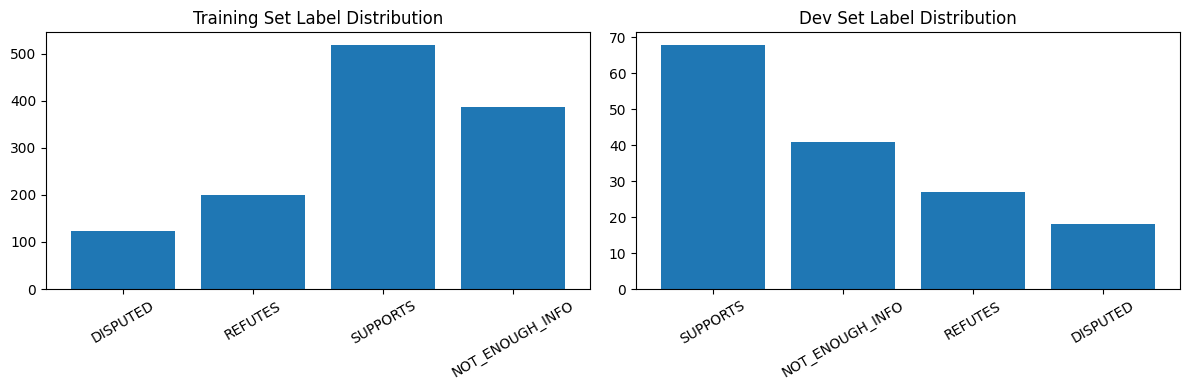

In [6]:
import matplotlib.pyplot as plt

# Label distribution plot — goes in the report
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(train_labels.keys(), train_labels.values())
ax[0].set_title('Training Set Label Distribution')
ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(dev_labels.keys(), dev_labels.values())
ax[1].set_title('Dev Set Label Distribution')
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_distribution.png'), dpi=150)
plt.show()

### 1.2 Text Preprocessing
We apply minimal preprocessing — lowercasing and whitespace normalization —
to preserve compatibility with pretrained Transformer tokenizers used later.

In [7]:
import re
import string

def preprocess(text):
    """Lowercase, normalize whitespace, strip basic punctuation noise."""
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

# Apply to a sample to verify
sample_claim = list(train_claims.values())[0]['claim_text']
print("Original: ", sample_claim)
print("Processed:", preprocess(sample_claim))

Original:  Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
Processed: not only is there no scientific evidence that co2 is a pollutant, higher co2 concentrations actually help ecosystems support more plant and animal life.


In [8]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab', quiet=True)

def tokenize_for_bm25(text):
    """Tokenize text for BM25 indexing."""
    return word_tokenize(preprocess(text))

# Test
print(tokenize_for_bm25("South Australia has the most expensive electricity in the world."))

['south', 'australia', 'has', 'the', 'most', 'expensive', 'electricity', 'in', 'the', 'world', '.']


In [9]:
LABEL2ID = {'SUPPORTS': 0, 'REFUTES': 1, 'NOT_ENOUGH_INFO': 2, 'DISPUTED': 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
print(LABEL2ID)

{'SUPPORTS': 0, 'REFUTES': 1, 'NOT_ENOUGH_INFO': 2, 'DISPUTED': 3}


In [10]:
print(f"Splits — Train: {len(train_claims)} | Dev: {len(dev_claims)} | Test: {len(test_claims)}")
print("Train and dev are used for development. Test is unlabelled — for leaderboard only.")

Splits — Train: 1228 | Dev: 154 | Test: 153
Train and dev are used for development. Test is unlabelled — for leaderboard only.


In [11]:
import pickle

cache_file = os.path.join(CACHE_DIR, 'evidence_tokenized.pkl')

if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        evidence_tokenized = pickle.load(f)
    print(f"Loaded cached tokenized evidence: {len(evidence_tokenized):,} passages")
else:
    print("Tokenizing evidence corpus (10-15 minutes)...")
    evidence_tokenized = {}
    for i, (eid, text) in enumerate(evidence.items()):
        evidence_tokenized[eid] = tokenize_for_bm25(text)
        if i % 100000 == 0:
            print(f"  {i:,} / {len(evidence):,}")
    with open(cache_file, 'wb') as f:
        pickle.dump(evidence_tokenized, f)
    print("Cached to Drive.")

Loaded cached tokenized evidence: 1,208,827 passages


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [17]:
!pip install rank_bm25 -q

In [18]:
from rank_bm25 import BM25Okapi
import pickle
import time

bm25_cache = os.path.join(CACHE_DIR, 'bm25_index.pkl')

if os.path.exists(bm25_cache):
    print("Loading cached BM25 index...")
    with open(bm25_cache, 'rb') as f:
        bm25, evidence_ids = pickle.load(f)
    print(f"Loaded BM25 index over {len(evidence_ids):,} passages")
else:
    print("Building BM25 index (3-5 minutes)...")
    t0 = time.time()

    # Preserve order: list of evidence_ids parallel to list of tokenized docs
    evidence_ids = list(evidence_tokenized.keys())
    tokenized_corpus = [evidence_tokenized[eid] for eid in evidence_ids]

    bm25 = BM25Okapi(tokenized_corpus)

    print(f"Built in {time.time()-t0:.1f}s. Caching...")
    with open(bm25_cache, 'wb') as f:
        pickle.dump((bm25, evidence_ids), f)
    print("Done.")

Loading cached BM25 index...
Loaded BM25 index over 1,208,827 passages


In [19]:
import numpy as np

def retrieve_bm25(claim_text, k=5):
    """Retrieve top-k evidence IDs for a claim using BM25."""
    query_tokens = tokenize_for_bm25(claim_text)
    scores = bm25.get_scores(query_tokens)
    top_k_idx = np.argsort(scores)[-k:][::-1]  # descending
    return [evidence_ids[i] for i in top_k_idx]

# Test on a dev claim with known ground truth
test_id = 'claim-752'
test_claim = dev_claims[test_id]
print(f"Claim: {test_claim['claim_text']}")
print(f"Ground truth evidences: {test_claim['evidences']}")
print(f"\nBM25 top 5:")
retrieved = retrieve_bm25(test_claim['claim_text'], k=5)
for eid in retrieved:
    print(f"  {eid}: {evidence[eid][:100]}...")
print(f"\nOverlap with ground truth: {set(retrieved) & set(test_claim['evidences'])}")

Claim: [South Australia] has the most expensive electricity in the world.
Ground truth evidences: ['evidence-67732', 'evidence-572512']

BM25 top 5:
  evidence-67732: [citation needed] South Australia has the highest retail price for electricity in the country....
  evidence-805395: The most common sound is the voiced nasal [[ɲ]]....
  evidence-572512: "South Australia has the highest power prices in the world"....
  evidence-442644: The [[Tibetan Plateau]] contains the world's third-largest store of ice....
  evidence-147175: Manhattan 's real estate market is among the most expensive in the world....

Overlap with ground truth: {'evidence-572512', 'evidence-67732'}


In [22]:
from tqdm import tqdm

def retrieve_all(claims_dict, k=5):
    """Retrieve top-k evidences for every claim. Returns dict: claim_id -> [evidence_ids]"""
    results = {}
    for claim_id, claim in tqdm(claims_dict.items()):
        results[claim_id] = retrieve_bm25(claim['claim_text'], k=k)
    return results

dev_retrieved = retrieve_all(dev_claims, k=5)
print(f"\nRetrieved evidences for {len(dev_retrieved)} dev claims")

100%|██████████| 154/154 [22:19<00:00,  8.70s/it]


Retrieved evidences for 154 dev claims


In [16]:
# Build a predictions JSON in the required format
bm25_predictions = {}
for claim_id, retrieved_evs in dev_retrieved.items():
    bm25_predictions[claim_id] = {
        'claim_text': dev_claims[claim_id]['claim_text'],
        'claim_label': 'SUPPORTS',  # placeholder — we'll fix this with the classifier
        'evidences': retrieved_evs
    }

pred_path = os.path.join(OUTPUT_DIR, 'dev-predictions-bm25.json')
with open(pred_path, 'w') as f:
    json.dump(bm25_predictions, f)

print("Predictions saved. Running eval...\n")
!python {PROJECT_DIR}/eval.py --predictions {pred_path} --groundtruth {DATA_DIR}/dev-claims.json

Predictions saved. Running eval...

Evidence Retrieval F-score (F)    = 0.09364048649762938
Claim Classification Accuracy (A) = 0.44155844155844154
Harmonic Mean of F and A          = 0.1545135653946439


In [18]:
import pandas as pd
import subprocess

# 優化：只執行一次最耗時的檢索（k=20）
print("Retrieving top-20 for all dev claims (once)...")
dev_retrieved_20 = retrieve_all(dev_claims, k=20)

ablation_results = []

# 針對不同的 k 進行切片測試
for k in [1, 3, 5, 10, 20]:
    print(f"Evaluating k={k}...")

    preds_k = {
        cid: {
            'claim_label': 'SUPPORTS', # 暫時預設標籤
            'evidences': evs[:k]
        } for cid, evs in dev_retrieved_20.items()
    }

    pred_path_k = os.path.join(OUTPUT_DIR, f'dev-predictions-bm25-k{k}.json')
    with open(pred_path_k, 'w') as f:
        json.dump(preds_k, f)

    # 執行評估腳本
    result = subprocess.run(
        ['python', os.path.join(PROJECT_DIR, 'eval.py'),
         '--predictions', pred_path_k,
         '--groundtruth', os.path.join(DATA_DIR, 'dev-claims.json')],
        capture_output=True, text=True
    )

    # 解析輸出中的 F-score
    for line in result.stdout.split('\n'):
        if 'F-score' in line:
            f_score = float(line.split('=')[1].strip())
            ablation_results.append({'k': k, 'F-score': f_score})

# 顯示最終比較表格
df_results = pd.DataFrame(ablation_results)
print("\n=== BM25 k-ablation (F-score on dev) ===")
print(df_results.to_string(index=False))

Retrieving top-20 for all dev claims (once)...


100%|██████████| 154/154 [26:30<00:00, 10.33s/it]



=== BM25 k-ablation (F-score on dev) ===
 k  F-score
 1 0.081602
 3 0.099289
 5 0.093640
10 0.072049
20 0.052853


Sentence Transformer

In [13]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

CUDA available: True
Device: Tesla T4


In [12]:
!pip install sentence-transformers -q

In [14]:
from sentence_transformers import SentenceTransformer

print("Loading sentence transformer model...")
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
encoder.to('cuda')
print(f"Model loaded. Max sequence length: {encoder.max_seq_length}")

Loading sentence transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Max sequence length: 256


In [15]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def rerank(claim_text, candidate_ids, top_k=5):
    """Re-rank candidate evidences using bi-encoder cosine similarity."""
    candidate_texts = [evidence[eid] for eid in candidate_ids]

    # Encode (model handles batching internally)
    claim_emb = encoder.encode(claim_text, convert_to_tensor=True, show_progress_bar=False)
    cand_embs = encoder.encode(candidate_texts, convert_to_tensor=True, show_progress_bar=False, batch_size=64)

    # Cosine similarity
    claim_emb = F.normalize(claim_emb.unsqueeze(0), dim=1)
    cand_embs = F.normalize(cand_embs, dim=1)
    scores = (claim_emb @ cand_embs.T).squeeze(0)

    # Top-k
    top_idx = torch.topk(scores, k=min(top_k, len(candidate_ids))).indices.cpu().numpy()
    return [candidate_ids[i] for i in top_idx]

In [20]:
test_id = 'claim-752'
test_claim = dev_claims[test_id]['claim_text']

# BM25 top 100
bm25_top100 = retrieve_bm25(test_claim, k=100)

# Re-rank to top 5
reranked = rerank(test_claim, bm25_top100, top_k=5)

print(f"Claim: {test_claim}")
print(f"Ground truth: {dev_claims[test_id]['evidences']}")
print(f"\nBM25 top 5:     {bm25_top100[:5]}")
print(f"Re-ranked top 5: {reranked}")
print(f"\nGold in BM25 top 5:     {set(bm25_top100[:5]) & set(dev_claims[test_id]['evidences'])}")
print(f"Gold in re-ranked top 5: {set(reranked) & set(dev_claims[test_id]['evidences'])}")

Claim: [South Australia] has the most expensive electricity in the world.
Ground truth: ['evidence-67732', 'evidence-572512']

BM25 top 5:     ['evidence-67732', 'evidence-805395', 'evidence-572512', 'evidence-442644', 'evidence-147175']
Re-ranked top 5: ['evidence-67732', 'evidence-572512', 'evidence-48256', 'evidence-976426', 'evidence-250017']

Gold in BM25 top 5:     {'evidence-572512', 'evidence-67732'}
Gold in re-ranked top 5: {'evidence-572512', 'evidence-67732'}


In [23]:
# Need top-100 from BM25 for re-ranking
print("Retrieving BM25 top-100 for all dev claims (~25-30 minutes)...")
dev_bm25_top100 = retrieve_all(dev_claims, k=100)

# Save it to cache so we never have to do this again
with open(os.path.join(CACHE_DIR, 'dev_bm25_top100.pkl'), 'wb') as f:
    pickle.dump(dev_bm25_top100, f)
print("Cached.")

Retrieving BM25 top-100 for all dev claims (~25-30 minutes)...


100%|██████████| 154/154 [22:14<00:00,  8.67s/it]

Cached.


In [24]:
print("Re-ranking with bi-encoder...")
dev_reranked = {}
for claim_id, candidates in tqdm(dev_bm25_top100.items()):
    claim_text = dev_claims[claim_id]['claim_text']
    dev_reranked[claim_id] = rerank(claim_text, candidates, top_k=5)
print("Done.")

Re-ranking with bi-encoder...


100%|██████████| 154/154 [00:12<00:00, 12.11it/s]

Done.


In [25]:
reranked_preds = {
    cid: {'claim_label': 'SUPPORTS', 'evidences': evs}
    for cid, evs in dev_reranked.items()
}

pred_path = os.path.join(OUTPUT_DIR, 'dev-predictions-reranked.json')
with open(pred_path, 'w') as f:
    json.dump(reranked_preds, f)

!python {PROJECT_DIR}/eval.py --predictions {pred_path} --groundtruth {DATA_DIR}/dev-claims.json

Evidence Retrieval F-score (F)    = 0.13816738816738816
Claim Classification Accuracy (A) = 0.44155844155844154
Harmonic Mean of F and A          = 0.2104752745698608


**Section 2.2 Claim Classifier**

In [26]:
!pip install transformers datasets -q

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
import torch
import numpy as np

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


In [27]:
def build_classifier_input(claim_text, evidence_ids, max_evidences=5):
    """Concatenate claim + evidences into a single input string."""
    selected_evs = evidence_ids[:max_evidences]
    evidence_text = ' '.join([evidence[eid] for eid in selected_evs])
    return claim_text, evidence_text  # tokenizer will add [SEP] between them

def make_dataset(claims_dict, use_gold=True):
    """Build a HuggingFace Dataset from a claims dict."""
    rows = []
    for claim_id, claim in claims_dict.items():
        evs = claim['evidences'] if use_gold else []
        claim_text, ev_text = build_classifier_input(claim['claim_text'], evs)
        rows.append({
            'claim_id': claim_id,
            'claim': claim_text,
            'evidence': ev_text,
            'label': LABEL2ID[claim['claim_label']]
        })
    return Dataset.from_list(rows)

train_ds = make_dataset(train_claims, use_gold=True)
dev_ds_gold = make_dataset(dev_claims, use_gold=True)  # for sanity-checking the classifier in isolation

print(f"Train examples: {len(train_ds)}")
print(f"Dev examples:   {len(dev_ds_gold)}")
print(f"\nExample:\n  Claim: {train_ds[0]['claim']}")
print(f"  Evidence: {train_ds[0]['evidence'][:200]}...")
print(f"  Label: {ID2LABEL[train_ds[0]['label']]}")

Train examples: 1228
Dev examples:   154

Example:
  Claim: Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
  Evidence: At very high concentrations (100 times atmospheric concentration, or greater), carbon dioxide can be toxic to animal life, so raising the concentration to 10,000 ppm (1%) or higher for several hours w...
  Label: DISPUTED


In [28]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 256  # claim + evidences fits well in 256 for most cases

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch['claim'],
        batch['evidence'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
    )

train_ds_tok = train_ds.map(tokenize_fn, batched=True)
dev_ds_gold_tok = dev_ds_gold.map(tokenize_fn, batched=True)

# Convert to PyTorch format
train_ds_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
dev_ds_gold_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization complete.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1228 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Tokenization complete.


In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    accuracy = (preds == labels).mean()
    return {'accuracy': accuracy}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

training_args = TrainingArguments(
    output_dir=os.path.join(CHECKPOINT_DIR, 'distilbert-classifier'),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=50,
    report_to='none',  # don't try to log to W&B
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tok,
    eval_dataset=dev_ds_gold_tok,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready. Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.259414,1.023579,0.584416
2,0.936532,0.969098,0.597403
3,0.858075,0.928252,0.629870


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=231, training_loss=0.9894960741976123, metrics={'train_runtime': 128.3754, 'train_samples_per_second': 28.697, 'train_steps_per_second': 1.799, 'total_flos': 244013651288064.0, 'train_loss': 0.9894960741976123, 'epoch': 3.0})

In [30]:
results = trainer.evaluate(dev_ds_gold_tok)
print(f"Classifier accuracy on dev with GOLD evidences: {results['eval_accuracy']:.4f}")

Classifier accuracy on dev with GOLD evidences: 0.6299


In [31]:
def predict_with_retrieved(claims_dict, retrieved_dict):
    """Run end-to-end: take retrieved evidences, predict labels."""
    rows = []
    for claim_id, claim in claims_dict.items():
        retrieved_evs = retrieved_dict[claim_id]
        claim_text, ev_text = build_classifier_input(claim['claim_text'], retrieved_evs)
        rows.append({
            'claim_id': claim_id,
            'claim': claim_text,
            'evidence': ev_text,
            'label': LABEL2ID[claim.get('claim_label', 'SUPPORTS')]  # placeholder for test
        })

    ds = Dataset.from_list(rows)
    ds_tok = ds.map(tokenize_fn, batched=True)
    ds_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

    predictions = trainer.predict(ds_tok)
    pred_labels = np.argmax(predictions.predictions, axis=-1)

    return {row['claim_id']: ID2LABEL[pred_labels[i]] for i, row in enumerate(rows)}

# Run end-to-end
pred_labels_dev = predict_with_retrieved(dev_claims, dev_reranked)

# Build final predictions JSON
final_preds = {}
for claim_id in dev_claims:
    final_preds[claim_id] = {
        'claim_label': pred_labels_dev[claim_id],
        'evidences': dev_reranked[claim_id]
    }

pred_path = os.path.join(OUTPUT_DIR, 'dev-predictions-full.json')
with open(pred_path, 'w') as f:
    json.dump(final_preds, f)

print("Final pipeline predictions saved. Running evaluation...\n")
!python {PROJECT_DIR}/eval.py --predictions {pred_path} --groundtruth {DATA_DIR}/dev-claims.json

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Final pipeline predictions saved. Running evaluation...

Evidence Retrieval F-score (F)    = 0.13816738816738816
Claim Classification Accuracy (A) = 0.4025974025974026
Harmonic Mean of F and A          = 0.20573022707779212


In [33]:
trainer.save_model(os.path.join(CHECKPOINT_DIR, 'distilbert-classifier-final'))
tokenizer.save_pretrained(os.path.join(CHECKPOINT_DIR, 'distilbert-classifier-final'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/COMP90042_Project/checkpoints/distilbert-classifier-final/tokenizer_config.json',
 '/content/drive/MyDrive/COMP90042_Project/checkpoints/distilbert-classifier-final/tokenizer.json')

In [34]:
import pickle
import json

# 儲存 Rerank 後的結果，避免重新跑 Bi-Encoder (雖然這一步不算太久，但存起來更保險)
rerank_cache_path = os.path.join(CACHE_DIR, 'dev_reranked_top5.pkl')
with open(rerank_cache_path, 'wb') as f:
    pickle.dump(dev_reranked, f)

# 儲存最終的預測結果 JSON (除了在 outputs，也可以存一個備份在 cache)
final_preds_path = os.path.join(CACHE_DIR, 'final_dev_predictions.json')
with open(final_preds_path, 'w') as f:
    json.dump(final_preds, f)

print(f"額外的快取檔案已儲存至: {CACHE_DIR}")

額外的快取檔案已儲存至: /content/drive/MyDrive/COMP90042_Project/cache


In [36]:
# Load a stronger pre-trained encoder
from sentence_transformers import SentenceTransformer

print("Loading multi-qa-MiniLM-L6-cos-v1 (designed for retrieval)...")
encoder_qa = SentenceTransformer('sentence-transformers/multi-qa-MiniLM-L6-cos-v1')
encoder_qa.to('cuda')

def rerank_v2(claim_text, candidate_ids, top_k=5):
    """Re-rank using the QA-trained encoder."""
    candidate_texts = [evidence[eid] for eid in candidate_ids]
    claim_emb = encoder_qa.encode(claim_text, convert_to_tensor=True, show_progress_bar=False)
    cand_embs = encoder_qa.encode(candidate_texts, convert_to_tensor=True, show_progress_bar=False, batch_size=64)

    claim_emb = F.normalize(claim_emb.unsqueeze(0), dim=1)
    cand_embs = F.normalize(cand_embs, dim=1)
    scores = (claim_emb @ cand_embs.T).squeeze(0)

    top_idx = torch.topk(scores, k=min(top_k, len(candidate_ids))).indices.cpu().numpy()
    return [candidate_ids[i] for i in top_idx]

print("Re-ranking with QA encoder...")
dev_reranked_qa = {}
for claim_id, candidates in tqdm(dev_bm25_top100.items()):
    claim_text = dev_claims[claim_id]['claim_text']
    dev_reranked_qa[claim_id] = rerank_v2(claim_text, candidates, top_k=5)

# Evaluate retrieval only
qa_preds = {
    cid: {'claim_label': 'SUPPORTS', 'evidences': evs}
    for cid, evs in dev_reranked_qa.items()
}
pred_path = os.path.join(OUTPUT_DIR, 'dev-predictions-reranked-qa.json')
with open(pred_path, 'w') as f:
    json.dump(qa_preds, f)

!python {PROJECT_DIR}/eval.py --predictions {pred_path} --groundtruth {DATA_DIR}/dev-claims.json

Loading multi-qa-MiniLM-L6-cos-v1 (designed for retrieval)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Re-ranking with QA encoder...


100%|██████████| 154/154 [00:10<00:00, 14.54it/s]


Evidence Retrieval F-score (F)    = 0.13536384250669967
Claim Classification Accuracy (A) = 0.44155844155844154
Harmonic Mean of F and A          = 0.20720658220881544


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

**3.1: Reload trained models (for reproducibility)**

In [37]:
# === Section 3: Testing and Evaluation ===
# This section assumes Sections 1 & 2 have been run.
# It loads the trained classifier and runs the full pipeline.

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import torch

# Reload classifier (in case session restarted)
classifier_path = os.path.join(CHECKPOINT_DIR, 'distilbert-classifier-final')
if os.path.exists(classifier_path):
    print(f"Loading classifier from {classifier_path}")
    tokenizer = AutoTokenizer.from_pretrained(classifier_path)
    classifier_model = AutoModelForSequenceClassification.from_pretrained(classifier_path)
    classifier_model.to('cuda')
    classifier_model.eval()
    print("Classifier loaded.")
else:
    print("WARNING: classifier checkpoint not found. Re-run Section 2 first.")

# Re-ranker should still be in memory as `encoder` from Section 2
# But verify
try:
    _ = encoder
    print("Re-ranker (encoder) is loaded.")
except NameError:
    print("Re-loading bi-encoder...")
    encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    encoder.to('cuda')

Loading classifier from /content/drive/MyDrive/COMP90042_Project/checkpoints/distilbert-classifier-final


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classifier loaded.
Re-ranker (encoder) is loaded.


**3.2: Unified pipeline function**

In [38]:
def run_pipeline(claims_dict, bm25_top100_cache=None, top_k=5):
    """
    Run full pipeline: BM25 → bi-encoder re-rank → classify.

    Args:
        claims_dict: dict of claim_id -> claim info (with claim_text)
        bm25_top100_cache: pre-computed BM25 top-100 dict (saves time)
        top_k: number of evidences to retrieve per claim

    Returns:
        dict of claim_id -> {'claim_label': ..., 'evidences': [...]}
    """
    # Step 1: BM25 top-100 (use cache if provided)
    if bm25_top100_cache is None:
        print("Running BM25 retrieval (slow)...")
        bm25_results = retrieve_all(claims_dict, k=100)
    else:
        bm25_results = bm25_top100_cache

    # Step 2: Re-rank with bi-encoder
    print("Re-ranking candidates...")
    reranked = {}
    for claim_id in tqdm(claims_dict):
        candidates = bm25_results[claim_id]
        reranked[claim_id] = rerank(
            claims_dict[claim_id]['claim_text'],
            candidates,
            top_k=top_k
        )

    # Step 3: Classify using retrieved evidences
    print("Classifying claims...")
    predictions = {}
    classifier_model.eval()
    with torch.no_grad():
        for claim_id, claim in tqdm(claims_dict.items()):
            retrieved = reranked[claim_id]
            claim_text = claim['claim_text']
            evidence_text = ' '.join([evidence[eid] for eid in retrieved])

            inputs = tokenizer(
                claim_text, evidence_text,
                truncation=True, padding='max_length',
                max_length=MAX_LENGTH, return_tensors='pt'
            ).to('cuda')

            logits = classifier_model(**inputs).logits
            pred_label = ID2LABEL[logits.argmax(dim=-1).item()]

            predictions[claim_id] = {
                'claim_label': pred_label,
                'evidences': retrieved
            }

    return predictions

**3.3: Run on dev set + evaluate**

In [39]:
# Run pipeline on dev set
print("=== Running pipeline on DEV set ===\n")
dev_predictions = run_pipeline(
    dev_claims,
    bm25_top100_cache=dev_bm25_top100,  # use the cached top-100 from Section 2
    top_k=5
)

# Save predictions
dev_pred_path = os.path.join(OUTPUT_DIR, 'dev-claims-predictions.json')
with open(dev_pred_path, 'w') as f:
    json.dump(dev_predictions, f, indent=2)
print(f"\nDev predictions saved to {dev_pred_path}")

# Evaluate
print("\n=== Final Dev Set Evaluation ===")
!python {PROJECT_DIR}/eval.py --predictions {dev_pred_path} --groundtruth {DATA_DIR}/dev-claims.json

=== Running pipeline on DEV set ===

Re-ranking candidates...


100%|██████████| 154/154 [00:14<00:00, 10.63it/s]


Classifying claims...


100%|██████████| 154/154 [00:01<00:00, 90.94it/s]



Dev predictions saved to /content/drive/MyDrive/COMP90042_Project/outputs/dev-claims-predictions.json

=== Final Dev Set Evaluation ===
Evidence Retrieval F-score (F)    = 0.13816738816738816
Claim Classification Accuracy (A) = 0.4025974025974026
Harmonic Mean of F and A          = 0.20573022707779212


**3.4: Confusion matrix (for the report)**

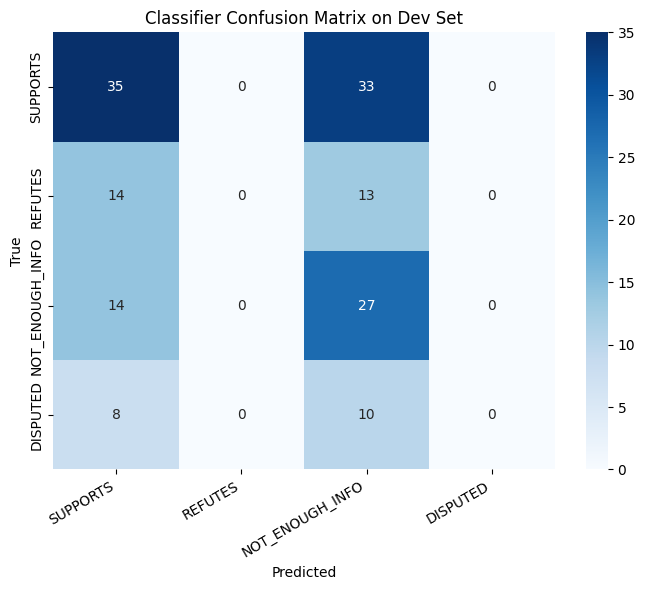


Per-class classification report:
                 precision    recall  f1-score   support

       SUPPORTS       0.49      0.51      0.50        68
        REFUTES       0.00      0.00      0.00        27
NOT_ENOUGH_INFO       0.33      0.66      0.44        41
       DISPUTED       0.00      0.00      0.00        18

       accuracy                           0.40       154
      macro avg       0.20      0.29      0.23       154
   weighted avg       0.30      0.40      0.34       154



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Build true and predicted label arrays
labels_order = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
y_true = [dev_claims[cid]['claim_label'] for cid in dev_claims]
y_pred = [dev_predictions[cid]['claim_label'] for cid in dev_claims]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Classifier Confusion Matrix on Dev Set')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# Per-class metrics
print("\nPer-class classification report:")
print(classification_report(y_true, y_pred, labels=labels_order, zero_division=0))

**3.5: Ablation table (for the report)**

In [45]:
# Add a proper baseline: always predict the majority class
majority_label = Counter(c['claim_label'] for c in train_claims.values()).most_common(1)[0][0]
print(f"Majority class in training: {majority_label}")

config_majority = {
    cid: {'claim_label': majority_label, 'evidences': dev_reranked[cid]}
    for cid in dev_claims
}

# Rebuild ablation table with clearer labels
rows = []

# Retrieval-only rows: report ONLY F-score, leave accuracy blank
f1, _, _ = quick_eval({cid: {'claim_label': 'X', 'evidences': dev_bm25_top100[cid][:5]} for cid in dev_claims}, dev_claims)
rows.append({'System': 'BM25 only (retrieval)', 'F-score': f1, 'Accuracy': '—', 'Harmonic Mean': '—'})

f2, _, _ = quick_eval({cid: {'claim_label': 'X', 'evidences': dev_reranked[cid]} for cid in dev_claims}, dev_claims)
rows.append({'System': 'BM25 + Bi-encoder rerank (retrieval)', 'F-score': f2, 'Accuracy': '—', 'Harmonic Mean': '—'})

# Classification baselines (with re-ranked retrieval)
f_maj, a_maj, hm_maj = quick_eval(config_majority, dev_claims)
rows.append({'System': f'Majority class baseline ({majority_label}) + rerank', 'F-score': f_maj, 'Accuracy': a_maj, 'Harmonic Mean': hm_maj})

# Full pipeline
f_full, a_full, hm_full = quick_eval(dev_predictions, dev_claims)
rows.append({'System': 'Full pipeline (rerank + DistilBERT)', 'F-score': f_full, 'Accuracy': a_full, 'Harmonic Mean': hm_full})

# Upper bound: classifier with GOLD evidences
print("Computing upper bound (classifier with gold evidences)...")
gold_predictions = {}
classifier_model.eval()
with torch.no_grad():
    for claim_id, claim in tqdm(dev_claims.items()):
        gold_evs = claim['evidences'][:5]
        ev_text = ' '.join([evidence[eid] for eid in gold_evs])
        inputs = tokenizer(claim['claim_text'], ev_text, truncation=True,
                          padding='max_length', max_length=MAX_LENGTH, return_tensors='pt').to('cuda')
        logits = classifier_model(**inputs).logits
        gold_predictions[claim_id] = {
            'claim_label': ID2LABEL[logits.argmax(dim=-1).item()],
            'evidences': gold_evs
        }

f_gold, a_gold, hm_gold = quick_eval(gold_predictions, dev_claims)
rows.append({'System': 'Upper bound: DistilBERT + GOLD evidences', 'F-score': f_gold, 'Accuracy': a_gold, 'Harmonic Mean': hm_gold})

ablation_df = pd.DataFrame(rows)
print("\n=== Ablation Table (Dev Set) ===")
print(ablation_df.to_string(index=False))

ablation_df.to_csv(os.path.join(OUTPUT_DIR, 'ablation_table.csv'), index=False)

Majority class in training: SUPPORTS
Computing upper bound (classifier with gold evidences)...


100%|██████████| 154/154 [00:04<00:00, 35.21it/s]


=== Ablation Table (Dev Set) ===
                                     System  F-score  Accuracy Harmonic Mean
                      BM25 only (retrieval) 0.093640         —             —
       BM25 + Bi-encoder rerank (retrieval) 0.138167         —             —
Majority class baseline (SUPPORTS) + rerank 0.138167  0.441558      0.210475
        Full pipeline (rerank + DistilBERT) 0.138167  0.402597       0.20573
   Upper bound: DistilBERT + GOLD evidences 1.000000   0.62987      0.772908


**3.6: Test set BM25 retrieval**

In [42]:
# BM25 top-100 for test claims
test_bm25_cache = os.path.join(CACHE_DIR, 'test_bm25_top100.pkl')
if os.path.exists(test_bm25_cache):
    print("Loading cached test BM25...")
    with open(test_bm25_cache, 'rb') as f:
        test_bm25_top100 = pickle.load(f)
    print(f"Loaded {len(test_bm25_top100)} test claims")
else:
    print(f"Retrieving BM25 top-100 for {len(test_claims)} test claims (~25 minutes)...")
    test_bm25_top100 = retrieve_all(test_claims, k=100)
    with open(test_bm25_cache, 'wb') as f:
        pickle.dump(test_bm25_top100, f)
    print("Cached.")

Retrieving BM25 top-100 for 153 test claims (~25 minutes)...


100%|██████████| 153/153 [21:57<00:00,  8.61s/it]

Cached.


**3.7: Test pipeline + final predictions file**

In [43]:
# Run full pipeline on test set
print("=== Running pipeline on TEST set ===\n")
test_predictions = run_pipeline(
    test_claims,
    bm25_top100_cache=test_bm25_top100,
    top_k=5
)

# Save in submission format
test_pred_path = os.path.join(OUTPUT_DIR, 'test-claims-predictions.json')
with open(test_pred_path, 'w') as f:
    json.dump(test_predictions, f, indent=2)

print(f"\nTest predictions saved to {test_pred_path}")
print(f"Sample prediction:")
sample_id = list(test_predictions.keys())[0]
print(json.dumps({sample_id: test_predictions[sample_id]}, indent=2))

=== Running pipeline on TEST set ===

Re-ranking candidates...


100%|██████████| 153/153 [00:10<00:00, 14.47it/s]


Classifying claims...


100%|██████████| 153/153 [00:01<00:00, 108.62it/s]


Test predictions saved to /content/drive/MyDrive/COMP90042_Project/outputs/test-claims-predictions.json
Sample prediction:
{
  "claim-2967": {
    "claim_label": "NOT_ENOUGH_INFO",
    "evidences": [
      "evidence-308923",
      "evidence-963856",
      "evidence-632574",
      "evidence-19067",
      "evidence-302863"
    ]
  }
}


**3.8: Sanity check the test predictions**

In [44]:
# Verify format matches what eval.py expects
print(f"Total test predictions: {len(test_predictions)}")
print(f"All have claim_label: {all('claim_label' in p for p in test_predictions.values())}")
print(f"All have evidences: {all('evidences' in p for p in test_predictions.values())}")
print(f"All evidences are lists: {all(isinstance(p['evidences'], list) for p in test_predictions.values())}")
print(f"All evidence lists non-empty: {all(len(p['evidences']) > 0 for p in test_predictions.values())}")
print(f"All labels valid: {all(p['claim_label'] in LABEL2ID for p in test_predictions.values())}")

# Label distribution on test
test_label_dist = Counter(p['claim_label'] for p in test_predictions.values())
print(f"\nPredicted test label distribution: {dict(test_label_dist)}")

Total test predictions: 153
All have claim_label: True
All have evidences: True
All evidences are lists: True
All evidence lists non-empty: True
All labels valid: True

Predicted test label distribution: {'NOT_ENOUGH_INFO': 84, 'SUPPORTS': 69}


In [46]:
# Confirm classifier is collapsing to 2 labels on dev too
from collections import Counter
dev_pred_dist = Counter(p['claim_label'] for p in dev_predictions.values())
dev_true_dist = Counter(c['claim_label'] for c in dev_claims.values())
print(f"Dev predicted distribution: {dict(dev_pred_dist)}")
print(f"Dev true distribution:      {dict(dev_true_dist)}")

Dev predicted distribution: {'NOT_ENOUGH_INFO': 83, 'SUPPORTS': 71}
Dev true distribution:      {'SUPPORTS': 68, 'NOT_ENOUGH_INFO': 41, 'REFUTES': 27, 'DISPUTED': 18}


## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*